In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from articulate import articulate
from omegaconf import OmegaConf
from dotenv import load_dotenv
from articulate_anything.utils.viz import (
    show_video, 
    display_code, 
    show_videos, 
    display_codes,
    show_images,
    get_frames_from_video,
)
from articulate_anything.utils.utils import load_config, join_path
from articulate_anything.utils.cotracker_utils import make_cotracker
from PIL import Image
import json

/home/rajsaha/miniforge3/envs/articulate-anything/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
pybullet build time: Jan 29 2025 23:16:28


In [3]:
import os
os.chdir("..")

In [4]:
## we have our API key stored in a .env file
## Comment the `load_dotenv` and `os.environ.get` lines if you just want to use
## your API key directly
load_dotenv()
API_KEY = os.environ.get('API_KEY')

task = "isaacsim_cabinet"

Let's first take a look at the ground-truth video

In [5]:
video_path = f"datasets/in-the-wild-dataset/videos/{task}.gif"

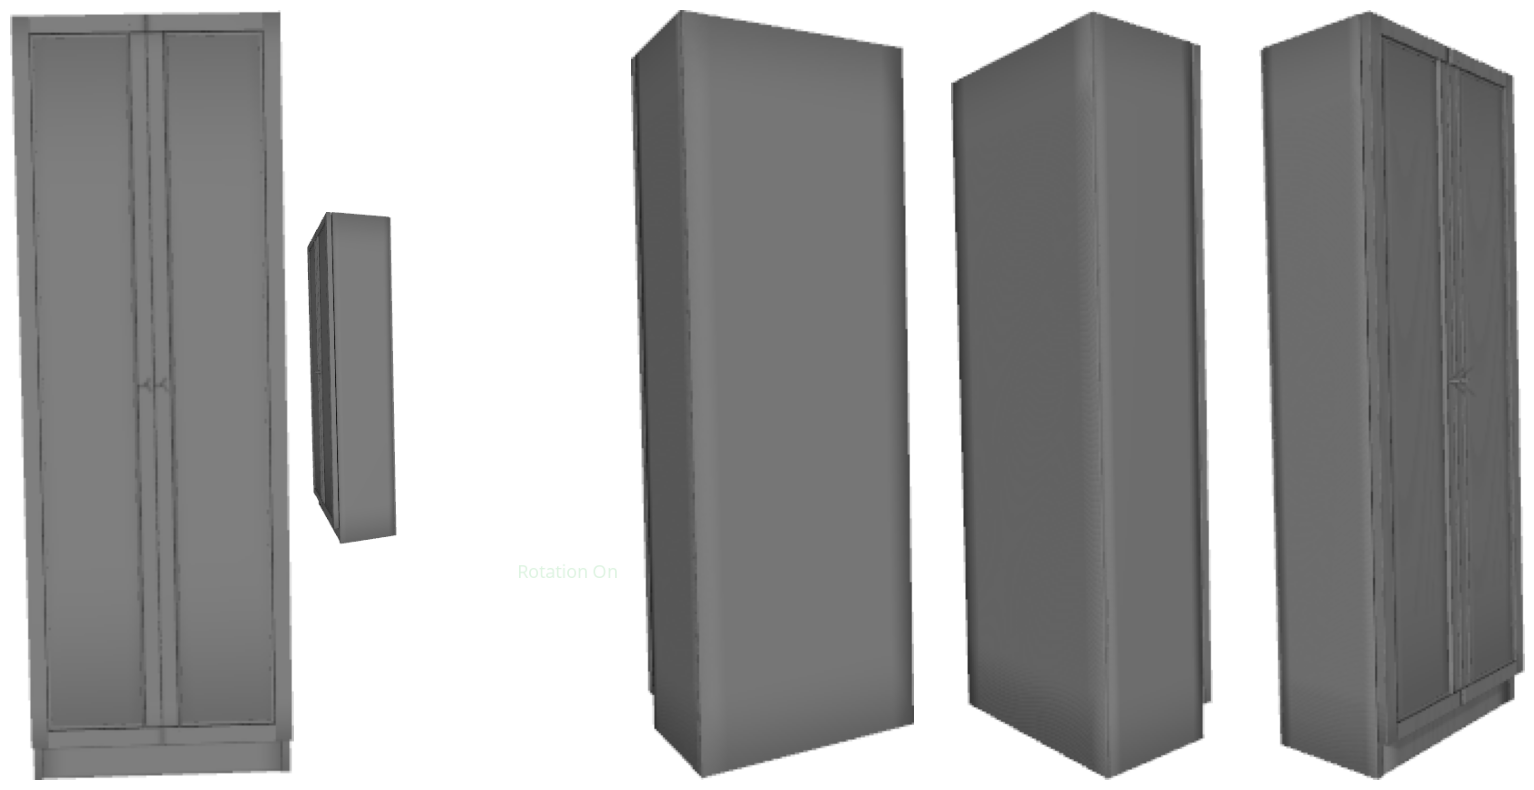

In [6]:
show_video(video_path)

Let's extract the first frame from the video and use that as the image prompt

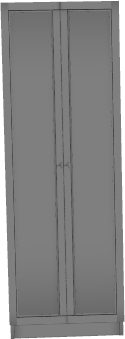

In [7]:
frames = get_frames_from_video(video_path,num_frames=5,)
frames[0]

In [8]:
if not os.path.exists("datasets/in-the-wild-dataset/images"):
    os.makedirs("datasets/in-the-wild-dataset/images")
image_path = f"datasets/in-the-wild-dataset/images/{task}.png"
frames[0].save(image_path)

Before starting articulation, please make sure that the dataset is preprocessed by running

   ```bash
   python articulate_anything/preprocess/preprocess_partnet.py parallel={int} modality={image}
   ```
This renders a front-view image for each object in the PartNet-Mobility dataset. This is necessary for our mesh retrieval as we will compare the visual similarity between the input image or video against each rendered template object.

In [10]:
modality = "image"
prompt = image_path

Note: currently Gemini does not support multi-modal prompt finetuning. We have to use few-shot prompting instead. It's important to pick the examples with some care for your use case.

In [11]:
cfg = load_config()
cfg.prompt = prompt
cfg.modality = modality
cfg.out_dir = join_path("results", modality, task)



use_cotracker = False # {True, False}
mode = "image"
actor_prompting_type = "basic" # {basic, incontext}
critic_prompting_type = "incontext" # {basic, incontext}

cfg.joint_actor.mode = mode
cfg.joint_actor.use_cotracker = use_cotracker
cfg.joint_actor.type = actor_prompting_type
cfg.joint_actor.targetted_affordance = False

cfg.joint_actor.examples_dir = "datasets/multi_modal_incontext_examples/joint_actor/in_context_actor_examples_datasets" ## Put your examples here


cfg.joint_critic.mode = mode
cfg.joint_critic.use_cotracker = use_cotracker
cfg.joint_critic.type = critic_prompting_type

cfg.joint_critic.examples_dir = "datasets/multi_modal_incontext_examples/joint_critic/in_context_examples_datasets" ## Put your examples here

cfg.actor_critic.actor_only = True

## important to set correctly for the joint_critic to works properly
## this should have the same direction as the ground-truth video
cfg.simulator.flip_video = False ## flip time for suitcase
cfg.simulator.ray_tracing=False
cfg.simulator.floor_texture = "plain"


# cfg.category_selector.topk = 3
cfg.category_selector.topk = 1 ## how many top categories should we search for an object template match
# this is because PartNet-Mobility dataset categories labels are sparse and sometimes not great


cfg.obj_selector.frame_index = 0

cfg.actor_critic.max_iter = 2
cfg.model_name = "gemini-1.5-flash-latest"


cfg.api_key = API_KEY ## loaded from .env file

In [12]:
steps = articulate(cfg)

INFO:root:Setting seed 0
INFO:root:Starting Mesh Retrieval
INFO:root:CategorySelector: Prediction already exists. Skipping generation.
INFO:root:ObjectSelector: Prediction already exists at results/image/isaacsim_cabinet/obj_selector/round_0_0/object_selector_result.json. Skipping generation.
INFO:root:ObjectSelector: Prediction already exists at results/image/isaacsim_cabinet/obj_selector/round_0_10/object_selector_result.json. Skipping generation.
INFO:root:ObjectSelector: Prediction already exists at results/image/isaacsim_cabinet/obj_selector/round_0_20/object_selector_result.json. Skipping generation.
INFO:root:ObjectSelector: Prediction already exists at results/image/isaacsim_cabinet/obj_selector/round_0_30/object_selector_result.json. Skipping generation.
INFO:root:ObjectSelector: Prediction already exists at results/image/isaacsim_cabinet/obj_selector/round_0_40/object_selector_result.json. Skipping generation.
INFO:root:ObjectSelector: Prediction already exists at results/ima

candidate_obj_ids ['35059', '38516', '40147', '40417', '40453', '41003', '41004', '41083', '41085', '41086', '41452', '41510', '41529', '44781', '44817', '44826', '44853', '44962', '45001', '45007', '45087', '45091', '45092', '45130', '45132', '45134', '45135', '45146', '45159', '45162', '45164', '45166', '45168', '45173', '45176', '45177', '45178', '45189', '45194', '45203', '45212', '45213', '45219', '45235', '45238', '45243', '45244', '45247', '45248', '45249', '45261', '45262', '45267', '45271', '45290', '45297', '45305', '45323', '45332', '45354', '45372', '45374', '45378', '45384', '45385', '45387', '45397', '45403', '45413', '45415', '45419', '45420', '45423', '45427', '45443', '45444', '45448', '45463', '45503', '45504', '45505', '45516', '45523', '45524', '45526', '45573', '45575', '45594', '45600', '45606', '45612', '45620', '45621', '45622', '45623', '45632', '45633', '45636', '45638', '45642', '45645', '45661', '45662', '45667', '45670', '45671', '45676', '45677', '45687', 

INFO:root:ObjectSelector: Prediction already exists at results/image/isaacsim_cabinet/obj_selector/round_0_60/object_selector_result.json. Skipping generation.
INFO:root:ObjectSelector: Prediction already exists at results/image/isaacsim_cabinet/obj_selector/round_0_70/object_selector_result.json. Skipping generation.
INFO:root:ObjectSelector: Prediction already exists at results/image/isaacsim_cabinet/obj_selector/round_0_80/object_selector_result.json. Skipping generation.
INFO:root:ObjectSelector: Prediction already exists at results/image/isaacsim_cabinet/obj_selector/round_0_90/object_selector_result.json. Skipping generation.
INFO:root:ObjectSelector: Prediction already exists at results/image/isaacsim_cabinet/obj_selector/round_0_100/object_selector_result.json. Skipping generation.
INFO:root:ObjectSelector: Prediction already exists at results/image/isaacsim_cabinet/obj_selector/round_0_110/object_selector_result.json. Skipping generation.
INFO:root:ObjectSelector: Prediction a

json_str: {
  "image_description": "The target image shows a tall, slender cabinet with two vertical doors. The doors are divided by a central vertical line and have simple, small handles near the center. The cabinet has a simple, rectangular shape with a slightly wider base.",
  "selected_image": "Image 9",
  "reasoning": "Image 9 is the most similar to the target image because it depicts a tall cabinet with two vertical doors.  While the proportions are slightly different and the style is simpler, the key features—two tall doors in a rectangular cabinet—match the target image.  The other images depict cabinets with different numbers of doors, drawers, or shapes, making them less similar to the target."
}


INFO:root:Prompt: ['Here is the target image:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=125x339 at 0x70690AB9D390>, '\n\nHere are the candidate images (numbered starting from 0):\n', '\nImage 0:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x70690AB81A80>, '\nImage 1:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x70690AB81870>, '\nImage 2:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x70690AB81B10>, '\nImage 3:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x70690AB818A0>, '\nImage 4:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x70690AB81930>, '\nImage 5:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x70690AB820E0>, '\nImage 6:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x70690AB82290>, '\nImage 7:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x70690AB820B0>, '\nImage 8:\n', <PIL.PngIm

...

pybullet build time: Jan 29 2025 23:16:28
[2025-04-18 11:44:15.084] [svulkan2] [error] Present requested but the selected device does not support present. Continue without present.

INFO:root:GT link diff is {'position_diff': {'furniture_body': 0.0, 'door': 0.013732990741730733, 'door_2': 0.013724988818169886}, 'orientation_diff': {'furniture_body': 0.0, 'door': 0.0, 'door_2': 0.0}}
INFO:root:At iteration 0, seed 0, Best result so far {'iteration': 0, 'seed': 0, 'pred_image_path': 'results/image/isaacsim_cabinet/link_placement/iter_0/seed_0/robot_frontview.png', 'link_pred_path': 'results/image/isaacsim_cabinet/link_placement/iter_0/seed_0/link_placement.py', 'gt_link_diff': {'position_diff': {'furniture_body': 0.0, 'door': 0.013732990741730733, 'door_2': 0.013724988818169886}, 'orientation_diff': {'furniture_body': 0.0, 'door': 0.0, 'door_2': 0.0}}, 'feedback_score': 10}
INFO:root:>>> Success with result {'iteration': 0, 'seed': 0, 'pred_image_path': 'results/image/isaacsim_cabinet/li

No. of link steps: 1
Picking the last link step
Link placement path: results/image/isaacsim_cabinet/link_placement/iter_0/seed_0/link_placement.py


INFO:root:JointPredictionActor: Generating content.
INFO:root:Prompt: ['The groundtruth image is\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=125x339 at 0x7068D2141780>, 'The link placement code is\n```python\nfrom articulate_anything.api.odio_urdf import *\n\n\ndef partnet_45444(input_dir, links):\n    """\n    No. masked_links: 4\n    Robot Link Summary:\n    - base\n    - door\n    - door_2\n    - furniture_body\n\n    Object: a cabinet with two doors\n    """\n    pred_robot = Robot(input_dir=input_dir, name="cabinet")\n    pred_robot.add_link(links[\'base\'])\n    pred_robot.add_link(links[\'furniture_body\'])\n    pred_robot.add_joint(Joint("base_to_furniture_body",\n                         Parent("base"),\n                         Child("furniture_body"),\n                         type="fixed"),\n                         )\n\n    pred_robot.add_link(links[\'door\'])\n    # cabinet doors go in front of the furniture body.\n    pred_robot.place_relative_to(\'door\', \

BEFORE FILTER VIDEO ['video_furniture_body_to_door_frontview.mp4', 'video_furniture_body_to_door_2_frontview.mp4']


INFO:root:Pipeline execution completed
INFO:root:Steps executed: Mesh Retrieval, Link actor, Link critic, Link Articulation, Joint actor, Joint critic, Joint Articulation


## Mesh Retrieval

Let's inspect the steps starting with the mesh retrieval

In [13]:
mesh_retrieval = steps["Mesh Retrieval"]
print(f"Mesh Retrieval: {mesh_retrieval}")

Mesh Retrieval: defaultdict(<class 'dict'>, {'Category Selection': <articulate_anything.agent.actor.mesh_retrieval.category_selector.CategorySelector object at 0x70690abb64a0>, 'Object Selection': <articulate_anything.agent.actor.mesh_retrieval.obj_selector.HierarchicalObjectSelector object at 0x70690abfe7a0>})


In [14]:
mesh_retrieval["Category Selection"].load_prediction()

{'target_object': 'a tall cabinet with two doors',
 'most_similar_objects': ['Cabinet'],
 'similarity_scores': [0.86376953125]}

In [15]:
obj_selector = mesh_retrieval["Object Selection"]
obj_selector.load_prediction()

{'selected_image': 'Image 75',
 'obj_ids': ['45444', '45696', '46655', '48018'],
 'obj_id': '45444'}

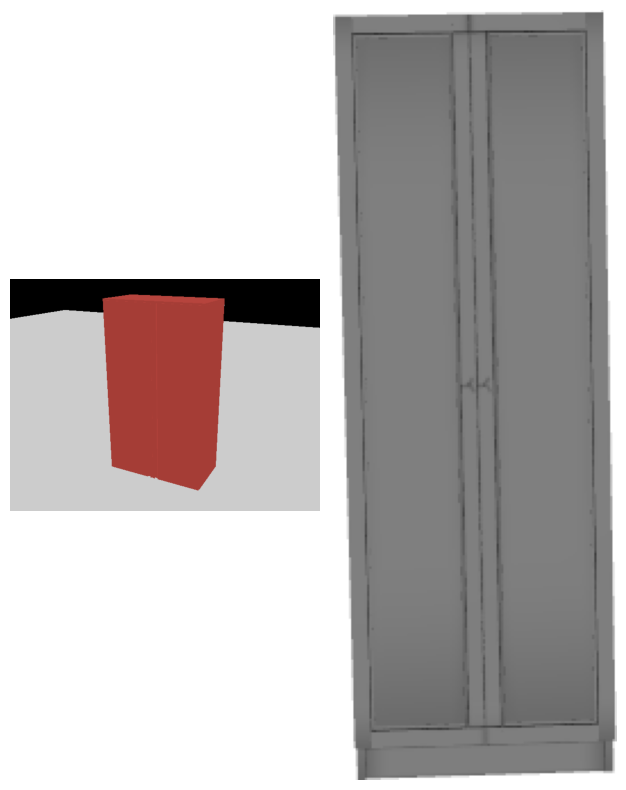

In [16]:
obj_selector.load_predicted_rendering()

## Link Placement

In [17]:
link_art = steps["Link Articulation"]
link_actors = link_art["Link actor"]
link_critics = link_art["Link critic"]
assert len(link_actors) == len(link_critics)
print(f"Link placement runs for {len(link_actors)} iteration(s)")

Link placement runs for 1 iteration(s)


In [18]:
link_codes = [link_actor.load_prediction() for link_actor in link_actors]

link_preds = [link_actor.load_predicted_rendering() for link_actor in link_actors]

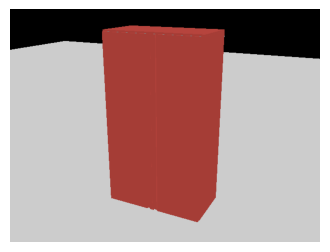

╷  
                                                             │  
╶────────────────────────────────────────────────────────────┼─╴
 from articulate_anything.api.odio_urdf import *             │  
                                                             │  
                                                             │  
 def partnet_45444(input_dir, links):                        │  
     """                                                     │  
     No. masked_links: 4                                     │  
     Robot Link Summary:                                     │  
     - base                                                  │  
     - door                                                  │  
     - door_2                                                │  
     - furniture_body                                        │  
                                                             │  
     Object: a cabinet with two doors                        │  
     """                                                     │  
     pred_robot = Robot(input_dir=input_dir, name="cabinet") │  
     pred_robot.add_link(links['base'])                      │  
     pred_robot.add_link(links['furniture_body'])            │  
     pred_robot.add_joint(Joint("base_to_furniture_body",    │  
                          Parent("base"),                    │  
                          Child("furniture_body"),           │  
                          type="fixed"),                     │  
                          )                                  │  
                                                             │  
     pred_robot.add_link(links['door'])                      │  
     # cabinet doors go in front of the furniture body.      │  
     pred_robot.place_relative_to('door', 'furniture_body',  │  
                                  placement="front",         │  
                                  clearance=0.0)             │  
                                                             │  
     pred_robot.add_link(links['door_2'])                    │  
     pred_robot.place_relative_to('door_2', 'furniture_body',│  
                                  placement="front",         │  
                                  clearance=0.0)             │  
     return pred_robot                                       │  
                                                             ╵

In [19]:
show_images(link_preds)
display_codes(link_codes)

Note: 
1. some object part names need relabeling because PartNet-Mobility part labeling is not great. For example, a lid's pump rod would be labeled as `lid` or a door knob would be labeled as `door`. **solution**: gemini annotation based on mesh images + maybe some manual relabeling. This is done automatically by the `preprocess_partnet.py` script.
2. Some meshes are also not "clean" so there would be floating points in the air that affect our collision detection algorithm  and thus our link placement but might not immediate visible to the eye. **solution**: use [open3d](https://www.open3d.org/docs/release/tutorial/geometry/mesh.html#Connected-components) to clean up the meshes.

## Joint Prediction

In [20]:
joint_art = steps["Joint Articulation"]
print(steps)
joint_actors = joint_art["Joint actor"]


print(f"Joint prediction runs for {len(joint_actors)} iteration(s)")

defaultdict(<class 'dict'>, {'Mesh Retrieval': defaultdict(<class 'dict'>, {'Category Selection': <articulate_anything.agent.actor.mesh_retrieval.category_selector.CategorySelector object at 0x70690abb64a0>, 'Object Selection': <articulate_anything.agent.actor.mesh_retrieval.obj_selector.HierarchicalObjectSelector object at 0x70690abfe7a0>}), 'Link actor': [<articulate_anything.agent.actor.link_placement.link_placement.LinkPlacementActor object at 0x7068d212eec0>], 'Link critic': [<articulate_anything.agent.critic.link_placement.link_critic.LinkCritic object at 0x7068d2bd7fd0>], 'Link Articulation': defaultdict(<class 'dict'>, {...}), 'Joint actor': [<articulate_anything.agent.actor.joint_prediction.joint_actor.JointPredictionActor object at 0x7068d2172ad0>], 'Joint critic': [<articulate_anything.agent.critic.joint_prediction.joint_critic.JointCriticMultiModalExamples object at 0x7068d21099f0>], 'Joint Articulation': defaultdict(<class 'dict'>, {...})})
Joint prediction runs for 1 iter

In [21]:
joint_codes = [joint_actor.load_prediction() for joint_actor in joint_actors]
joint_preds = [joint_actor.load_predicted_rendering() for joint_actor in joint_actors]


BEFORE FILTER VIDEO ['video_furniture_body_to_door_frontview.mp4', 'video_furniture_body_to_door_2_frontview.mp4']


""

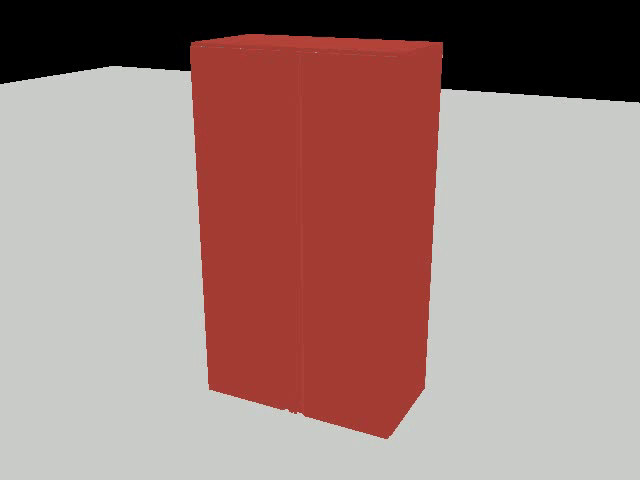

╷  
                                                                                                         │  
╶────────────────────────────────────────────────────────────────────────────────────────────────────────┼─╴
 from articulate_anything.api.odio_urdf import *                                                         │  
                                                                                                         │  
                                                                                                         │  
 def partnet_45444(input_dir, links):                                                                    │  
     """                                                                                                 │  
     No. masked_links: 4                                                                                 │  
     Robot Link Summary:                                                                                 │  
     - base                                                                                              │  
     - door                                                                                              │  
     - door_2                                                                                            │  
     - furniture_body                                                                                    │  
                                                                                                         │  
     Object: a cabinet with two doors                                                                    │  
     """                                                                                                 │  
     pred_robot = Robot(input_dir=input_dir, name="cabinet")                                             │  
     pred_robot.add_link(links['base'])                                                                  │  
     pred_robot.add_link(links['furniture_body'])                                                        │  
     pred_robot.add_joint(Joint("base_to_furniture_body",                                                │  
                          Parent("base"),                                                                │  
                          Child("furniture_body"),                                                       │  
                          type="fixed"),                                                                 │  
                          )                                                                              │  
                                                                                                         │  
     pred_robot.add_link(links['door'])                                                                  │  
     # cabinet doors go in front of the furniture body.                                                  │  
     pred_robot.place_relative_to('door', 'furniture_body',                                              │  
                                  placement="front",                                                     │  
                                  clearance=0.0)                                                         │  
                                                                                                         │  
     pred_robot.add_link(links['door_2'])                                                                │  
     pred_robot.place_relative_to('door_2', 'furniture_body',                                            │  
                                  placement="front",                                                     │  
                                  clearance=0.0)                                                         │  
     # ====================JOINT PREDICTION====================                                          │  
     # we're rotating at an edge of the door instead of the center      

In [22]:
show_videos(joint_preds, width=512, height=512)
display_codes(joint_codes)